End to End Implementation fo Alex Net Arch from dataset to model Arch to Training to Evaluation
(Some Modification wrt usae of data and training method is nessosory to train this model on Single Core GPU in Laptop, Arch Remains same.)

### Set Up

In [1]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [2]:
import keras
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
# from keras.src.legacy.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report
from sklearn.neighbors import NearestNeighbors
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Dataset, DataLoader
from PIL import Image

In [3]:
torch.cuda.is_available()

True

In [4]:
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32 = True
keras.mixed_precision.set_global_policy("mixed_float16")
keras.config.set_image_data_format("channels_first")
print(keras.config.image_data_format())

channels_first


In [5]:
model_name = "alexnet_trainset_30_epochs.keras"

### The Dataset (3)

> Info : ImageNet dataset of over 15 million labeled high- resolution
images belonging to roughly 22,000 categories.

> Paper : ILSVRC uses a subset of ImageNet with roughly 1000 images in each of 1000 categories.
In all, there are roughly 1.2 million training images, 50,000 validation images, and 150,000 testing images.
Paper uses all these images

> Me : We use 1261406 (~1.26 M) labeled high-resolution imaged of ImageNet same train dataset paper used and
       same validation set for validating and evaluating the model.
       We are not using test dataset has we dint get hands on their labels, somehow the paper authors got them.

> Paper : Down-sampled the images to a fixed resolution of 256 × 256. Given a rectangular image, we first rescaled the image such that the shorter side was of length 256, and then cropped out the central 256 × 256 patch from the resulting image. Then subtracting the mean activity over the training set from each pixel.

> Me : Implemented this data preprocessing as utils



In [6]:
dir = "ILSVRC2010_images"
print(f"Validation images: {len(os.listdir(os.path.join(dir, 'val')))}")

Validation images: 50000


In [7]:
from scipy.io import loadmat
meta = loadmat(os.path.join(dir, "meta.mat"))
synsets = meta["synsets"]
print(meta.keys())
print(synsets)

dict_keys(['__header__', '__version__', '__globals__', 'cost_matrix', 'synsets'])
[[(array([[1]], dtype=uint8), array(['n07711080'], dtype='<U9'), array(['french fries, french-fried potatoes, fries, chips'], dtype='<U49'), array(['strips of potato fried in deep fat'], dtype='<U34'), array([[0]], dtype=uint8), array([], shape=(1, 0), dtype=uint8), array([[0]], dtype=uint8), array([[1487]], dtype=uint16))]
 [(array([[2]], dtype=uint8), array(['n07711569'], dtype='<U9'), array(['mashed potato'], dtype='<U13'), array(['potato that has been peeled and boiled and then mashed'],
        dtype='<U54'), array([[0]], dtype=uint8), array([], shape=(1, 0), dtype=uint8), array([[0]], dtype=uint8), array([[1245]], dtype=uint16))                         ]
 [(array([[3]], dtype=uint8), array(['n07767549'], dtype='<U9'), array(['black olive, ripe olive'], dtype='<U23'), array(['olives picked ripe and cured in brine then dried or pickled or preserved canned or in oil'],
        dtype='<U89'), array([[0]

In [8]:
print(meta["synsets"].shape)
print(meta["synsets"][0,0])

(1676, 1)
(array([[1]], dtype=uint8), array(['n07711080'], dtype='<U9'), array(['french fries, french-fried potatoes, fries, chips'], dtype='<U49'), array(['strips of potato fried in deep fat'], dtype='<U34'), array([[0]], dtype=uint8), array([], shape=(1, 0), dtype=uint8), array([[0]], dtype=uint8), array([[1487]], dtype=uint16))


In [9]:
rows = []
for s in synsets:
    s = s[0]
    ilsvrc_id = int(s[0][0][0])      # 1..1000 (or other ids)
    wnid = s[1][0]                   # e.g. n01440764
    words = s[2][0]                  # class name
    num_children = int(s[4][0][0])   # leaf nodes have 0 children
    rows.append([ilsvrc_id, wnid, words, num_children])

df = pd.DataFrame(rows, columns=["id", "wnid", "class_name", "children"])
print(len(df))
df.head()

1676


,id,wnid,class_name,children
0,1,n07711080,"french fries, french-fried potatoes, fries, chips",0
1,2,n07711569,mashed potato,0
2,3,n07767549,"black olive, ripe olive",0
3,4,n03314780,face powder,0
4,5,n07739344,"crab apple, crabapple",0


In [10]:
imagenet1000 = (df[df["children"] == 0].sort_values("id").reset_index(drop=True))
print(len(imagenet1000))
imagenet1000.head()

1000


,id,wnid,class_name,children
0,1,n07711080,"french fries, french-fried potatoes, fries, chips",0
1,2,n07711569,mashed potato,0
2,3,n07767549,"black olive, ripe olive",0
3,4,n03314780,face powder,0
4,5,n07739344,"crab apple, crabapple",0


In [11]:
mapping = dict(zip(imagenet1000["id"], imagenet1000["wnid"]))
mapping

{1: 'n07711080',
 2: 'n07711569',
 3: 'n07767549',
 4: 'n03314780',
 5: 'n07739344',
 6: 'n07742313',
 7: 'n07745940',
 8: 'n07743544',
 9: 'n07743902',
 10: 'n07744246',
 11: 'n07744811',
 12: 'n07745466',
 13: 'n07746186',
 14: 'n07767171',
 15: 'n07747607',
 16: 'n07749446',
 17: 'n07749582',
 18: 'n07749969',
 19: 'n07751451',
 20: 'n07753113',
 21: 'n07753275',
 22: 'n07753592',
 23: 'n07754684',
 24: 'n07757132',
 25: 'n07758680',
 26: 'n07760859',
 27: 'n07762913',
 28: 'n07764155',
 29: 'n07765208',
 30: 'n07765361',
 31: 'n07766173',
 32: 'n07768694',
 33: 'n07769584',
 34: 'n07727048',
 35: 'n07729485',
 36: 'n07725531',
 37: 'n07726095',
 38: 'n07720277',
 39: 'n07723559',
 40: 'n07732747',
 41: 'n07736692',
 42: 'n07720875',
 43: 'n07721195',
 44: 'n07721678',
 45: 'n07734292',
 46: 'n07735404',
 47: 'n07735803',
 48: 'n07713763',
 49: 'n07714448',
 50: 'n07714571',
 51: 'n07714990',
 52: 'n07715103',
 53: 'n07715221',
 54: 'n07716358',
 55: 'n07716906',
 56: 'n07717410',
 

### Data Augmentation (5.1)

From Paper :
The first form of data augmentation consists of generating image translations and horizontal reflections.
We do this by extracting random 224 × 224 patches (and their horizontal reflections) from the 256 × 256 images
and training our network on these extracted patches.


The second form of data augmentation consists of altering the intensities of the RGB channels in training images.
Specifically, we perform PCA on the set of RGB pixel values throughout the ImageNet training set.
To each training image, we add multiples of the found principal components, with magnitudes proportional to the corresponding
eigen values times a random variable drawn from a Gaussian with mean 0 and standard deviation 0.1.

Note : We Skipping PCA Augmentation

In [12]:
# preprocess utils
IMAGENET_MEAN = tf.constant([123.68, 116.779, 103.939], dtype=tf.float32) # Fixed commonly used mean, paper computed it for their e dataset might be different, dint publish those.
preprocess = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomCrop(224), # TODO Center Corp : tf.image.resize_with_crop_or_pad(image, target_height=224, target_width=224)
    transforms.RandomHorizontalFlip(),
    # Substract Mean : tf.cast(image, tf.float32) - IMAGENET_MEAN is default done by this pipeline.
    transforms.ToTensor()
])

In [13]:
label_path = os.path.join(dir, "ILSVRC2010_validation_ground_truth.txt")
val_df = pd.read_csv(label_path, header=None)
val_df.columns = pd.Index(["class"])
val_df["id"] = val_df.index+1
val_df["id"] = val_df["id"].astype(str).str.zfill(5)
val_df['class'] = val_df["class"].astype(int).map(mapping)
val_df

,class,id
0,n09428293,00001
1,n02871525,00002
2,n02119789,00003
3,n04141975,00004
4,n03000247,00005
...,...,...
49995,n01728572,49996
49996,n03351979,49997
49997,n09246464,49998
49998,n13136316,49999


In [14]:
prefix = "ILSVRC2010_val_000"
val_df['id'] = prefix+val_df['id'].astype(str) + '.JPEG'

In [15]:
train_dataset = ImageFolder(os.path.join(dir, "train"), transform=preprocess)
train_data = DataLoader(train_dataset, batch_size=192, shuffle=True, num_workers=8, pin_memory=True, persistent_workers=True, prefetch_factor=4)

In [16]:
images, labels = next(iter(train_data))
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([192, 3, 224, 224])
Labels batch shape: torch.Size([192])


In [17]:
labels[0]

tensor(584)

In [18]:
np.argmax(labels[0])

tensor(0)

In [19]:
images[0]

tensor([[[0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
         [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
         [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
         ...,
         [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
         [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961],
         [0.9961, 0.9961, 0.9961,  ..., 0.9961, 0.9961, 0.9961]],

        [[0.9882, 0.9882, 0.9882,  ..., 0.9882, 0.9882, 0.9882],
         [0.9882, 0.9882, 0.9882,  ..., 0.9882, 0.9882, 0.9882],
         [0.9882, 0.9882, 0.9882,  ..., 0.9882, 0.9882, 0.9882],
         ...,
         [0.9882, 0.9882, 0.9882,  ..., 0.9882, 0.9882, 0.9882],
         [0.9882, 0.9882, 0.9882,  ..., 0.9882, 0.9882, 0.9882],
         [0.9882, 0.9882, 0.9882,  ..., 0.9882, 0.9882, 0.9882]],

        [[0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922],
         [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.9922],
         [0.9922, 0.9922, 0.9922,  ..., 0.9922, 0.9922, 0.

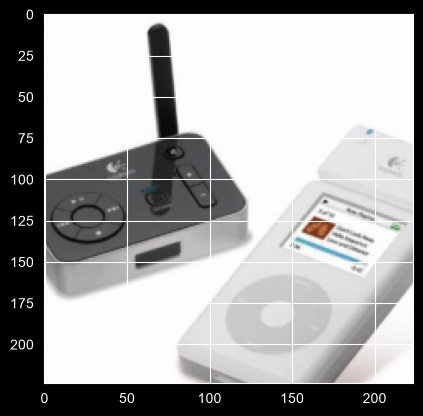

In [20]:
plt.imshow(np.transpose(images[0], (1, 2, 0)))
plt.show()

In [21]:
class ImageNetValDataset(Dataset):
    def __init__(self, dataframe, img_dir, transform=None, class_to_idx=None):
        self.dataframe = dataframe
        self.img_dir = img_dir
        self.transform = transform
        self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        img_name = self.dataframe.iloc[idx]['id']
        img_path = os.path.join(self.img_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        wnid_label = self.dataframe.iloc[idx]['class']
        label = self.class_to_idx[wnid_label]
        if self.transform:
            image = self.transform(image)
        return image, label

val_dataset = ImageNetValDataset(
    dataframe=val_df,
    img_dir=os.path.join(dir, "val"),
    transform=preprocess,
    class_to_idx=train_dataset.class_to_idx)


val_data = DataLoader(val_dataset, batch_size=192, shuffle=False, num_workers=0, pin_memory=True)

In [22]:
images, labels = next(iter(val_data))
print("Images batch shape:", images.shape)
print("Labels batch shape:", labels.shape)

Images batch shape: torch.Size([192, 3, 224, 224])
Labels batch shape: torch.Size([192])


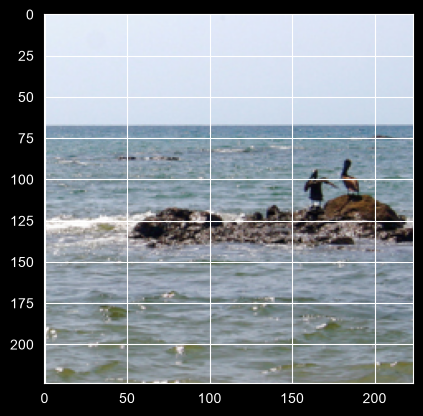

In [23]:
plt.imshow(np.transpose(images[0], (1, 2, 0)))
plt.show()

### Model Architecture (4)

In [24]:
# 4.3. Local response normalization
@keras.saving.register_keras_serializable()
class LocalResponseNormalization(keras.layers.Layer):
    def call(self, x):
        return torch.nn.functional.local_response_norm(x, size=5, alpha=1e-4, beta=0.75, k=2.0, )

In [25]:
inputs = keras.Input(shape=(3, 224, 224))

x = keras.layers.ZeroPadding2D(2)(inputs) # Padding for original conv size, embedded implementation in paper code, Can be skipped.

# Layer1
x = keras.layers.Conv2D(filters=96, kernel_size=11, strides=4, padding="valid", activation="relu", name="conv1",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x) # Weight Decay using l2 From (6). ReLU from (5.1
x = LocalResponseNormalization(name="lrn1")(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool1")(x)

# Layer2
x = keras.layers.Conv2D(filters=256, kernel_size=5, strides=1, padding="same", activation="relu", name="conv2",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = LocalResponseNormalization(name="lrn2")(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool2")(x)

# Layer3
x = keras.layers.Conv2D(filters=384, kernel_size=3, strides=1, padding="same", activation="relu", name="conv3",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)

# Layer4
x = keras.layers.Conv2D(filters=384, kernel_size=3, strides=1, padding="same", activation="relu", name="conv4",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)

# Layer5
x = keras.layers.Conv2D(filters=256, kernel_size=3, strides=1, padding="same", activation="relu", name="conv5",
                        kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.MaxPooling2D(pool_size=3, strides=2, name="pool5")(x)

# Layer 6
x = keras.layers.Flatten(name="flatten")(x)
x = keras.layers.Dense(4096, activation="relu", name="dense1", kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.Dropout(0.5)(x) # From 5.2

# Layer 7
x = keras.layers.Dense(4096, activation="relu", name="dense2", kernel_regularizer=keras.regularizers.l2(5e-4))(x)
x = keras.layers.Dropout(0.5)(x) # From 5.2

# Layer 8
outputs = keras.layers.Dense(1000, activation="softmax", name="dense3", kernel_regularizer=keras.regularizers.l2(5e-4))(x)

model = keras.Model(inputs, outputs)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 3, 228, 228)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 55, 55)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn1                            │ (None, 96, 55, 55)     │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 96, 27, 27)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 256, 27, 27)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn2                            │ (None, 256, 27, 27)    │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 256, 13, 13)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 384, 13, 13)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 384, 13, 13)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 256, 13, 13)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 256, 6, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 62,378,344 (237.95 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

Model Arch Diagram from Paper :

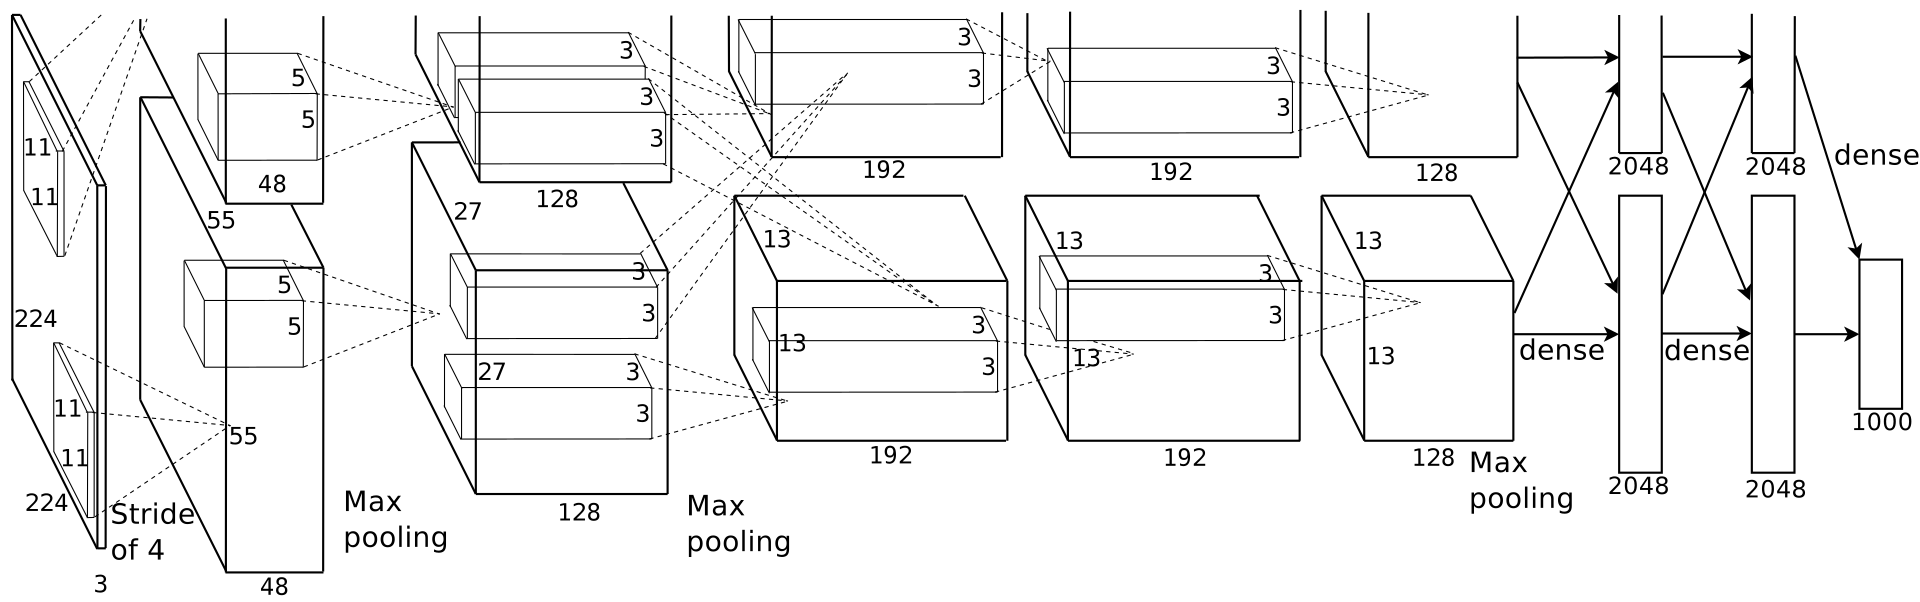

### Training/Learning (6)

From Paper :

We trained our models using stochastic gradient descent with a batch size of 128 examples, momentum of 0.9, and weight decay of 0.0005.


We initialized the weights in each layer from a zero-mean Gaussian distribution with standard deviation 0.01.
We initialized the neuron biases in the second, fourth, and fifth convolutional layers, as well as in the fully connected hidden
layers, with the constant 1.
This initialization accelerates the early stages of learning by providing the ReLUs with positive inputs.
We initialized the neuron biases in the remaining layers with the constant 0

Note : We leave all Weight Initialization to keras library default

In [26]:
# Optimizer
optimizer = keras.optimizers.SGD(learning_rate=0.01, momentum=0.9) # Paper usage

In [27]:
torch.backends.cudnn.benchmark = True
if os.path.exists(model_name): # Mechanism to continue training model from where it stopped
    model = keras.models.load_model(model_name)
else:
    model.compile(optimizer=optimizer, loss="sparse_categorical_crossentropy", metrics=[
    keras.metrics.SparseCategoricalAccuracy(name="accuracy"), keras.metrics.SparseTopKCategoricalAccuracy(k=5, name="top5")])

In [28]:
# LR Scheduler
reduce_lr = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.1, patience=5, verbose=1)

In [29]:
checkpoint = keras.callbacks.ModelCheckpoint(model_name, monitor="val_accuracy", save_best_only=True)

In [30]:
# Training : Paper used 90 Epochs. We Used Same, ~25 Min per Epoch. Took 45 Hrs
history = model.fit(train_data, validation_data=val_data, epochs=30, callbacks=[reduce_lr, checkpoint])
"""
Observation done when looking at training logs :
Epoch   Acc     Loss    Top5    ValACC  ValLoss ValTop5
5       26.32   4.6     50.23   30.1    4.4     54.81
10      32.97   4.44    58.0    34.8    4.33    60.27
15      35.14   4.4     60.43   37.6    4.25    63.26
20      45.91   3.65    70.4    47.27   3.57    71.55
25      47.68   3.3     72.03   48.0    3.31    72.15
30      48.61   3.2     72.84   48.27   3.23    72.25
35
40
45
50
55
60
LR : 0.001 (set at Epoch 18 from 0.01)
"""

C:\Users\PRASHANTH N\PycharmProjects\PaperClip\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a torch DataLoader. The DataLoader is expected to already be shuffled.
  self.data_adapter = data_adapters.get_data_adapter(


Epoch 1/30
6570/6570 ━━━━━━━━━━━━━━━━━━━━ 1556s 234ms/step - accuracy: 0.0177 - loss: 9.8172 - top5: 0.0604 - val_accuracy: 0.0635 - val_loss: 7.1291 - val_top5: 0.1858 - learning_rate: 0.0100
Epoch 2/30
6570/6570 ━━━━━━━━━━━━━━━━━━━━ 1544s 235ms/step - accuracy: 0.1102 - loss: 6.1051 - top5: 0.2722 - val_accuracy: 0.1656 - val_loss: 5.2555 - val_top5: 0.3702 - learning_rate: 0.0100
Epoch 3/30
6570/6570 ━━━━━━━━━━━━━━━━━━━━ 1511s 230ms/step - accuracy: 0.1843 - loss: 5.0677 - top5: 0.3947 - val_accuracy: 0.2316 - val_loss: 4.6831 - val_top5: 0.4624 - learning_rate: 0.0100
Epoch 4/30
6570/6570 ━━━━━━━━━━━━━━━━━━━━ 1708s 260ms/step - accuracy: 0.2328 - loss: 4.7259 - top5: 0.4630 - val_accuracy: 0.2666 - val_loss: 4.5278 - val_top5: 0.5083 - learning_rate: 0.0100
Epoch 5/30
6570/6570 ━━━━━━━━━━━━━━━━━━━━ 1477s 224ms/step - accuracy: 0.2632 - loss: 4.6041 - top5: 0.5023 - val_accuracy: 0.3010 - val_loss: 4.4008 - val_top5: 0.5481 - learning_rate: 0.0100
Epoch 6/30
6570/6570 ━━━━━━━━━━━━━━

### Evaluation Plots

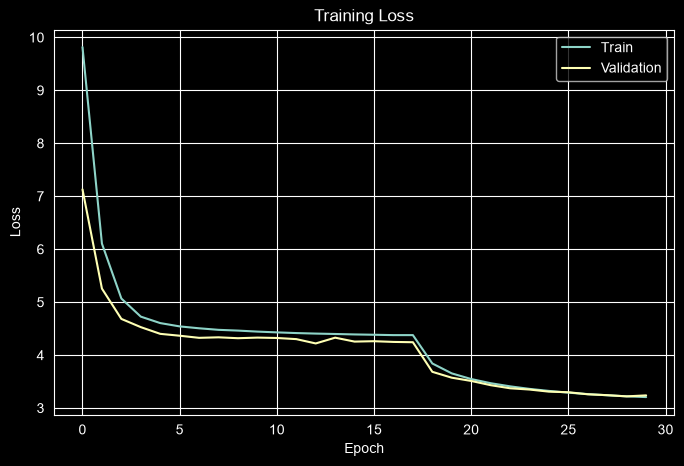

In [31]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.legend()
plt.show()

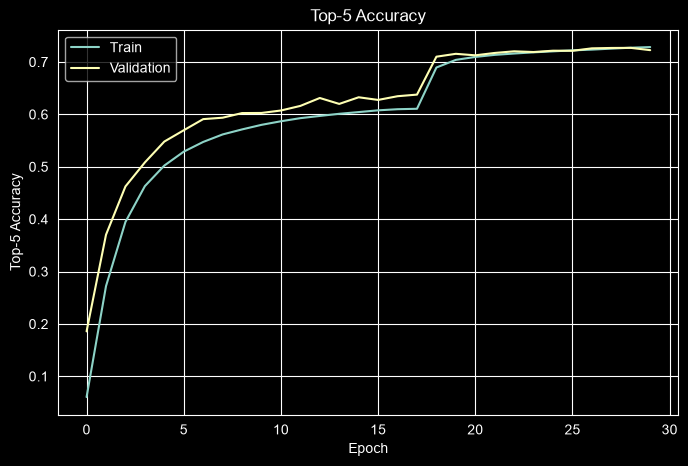

In [32]:
plt.figure(figsize=(8,5))
plt.plot(history.history["top5"], label="Train")
plt.plot(history.history["val_top5"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Top-5 Accuracy")
plt.title("Top-5 Accuracy")
plt.legend()
plt.show()

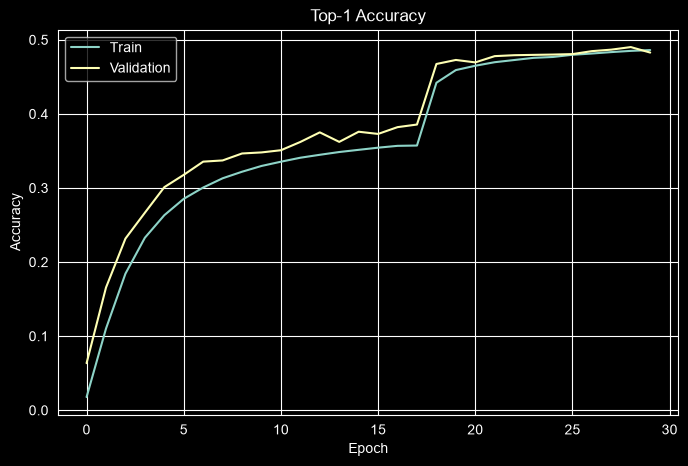

In [33]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Top-1 Accuracy")
plt.legend()
plt.show()

### Evaluation

In [34]:
@keras.saving.register_keras_serializable()
class LocalResponseNormalization(keras.layers.Layer):
    def call(self, x):
        return torch.nn.functional.local_response_norm(x, size=5, alpha=1e-4, beta=0.75, k=2.0, )

model = keras.models.load_model(model_name)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 3, 224, 224)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ zero_padding2d (ZeroPadding2D)  │ (None, 3, 228, 228)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 96, 55, 55)     │        34,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn1                            │ (None, 96, 55, 55)     │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool1 (MaxPooling2D)            │ (None, 96, 27, 27)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 256, 27, 27)    │       614,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lrn2                            │ (None, 256, 27, 27)    │             0 │
│ (LocalResponseNormalization)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool2 (MaxPooling2D)            │ (None, 256, 13, 13)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3 (Conv2D)                  │ (None, 384, 13, 13)    │       885,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv4 (Conv2D)                  │ (None, 384, 13, 13)    │     1,327,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv5 (Conv2D)                  │ (None, 256, 13, 13)    │       884,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pool5 (MaxPooling2D)            │ (None, 256, 6, 6)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense1 (Dense)                  │ (None, 4096)           │    37,752,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense2 (Dense)                  │ (None, 4096)           │    16,781,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense3 (Dense)                  │ (None, 1000)           │     4,097,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,756,694 (475.91 MB)

 Trainable params: 62,378,344 (237.95 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 62,378,350 (237.95 MB)

In [35]:
results = model.evaluate(val_data)

print(f"Loss          : {results[0]:.4f}")
print(f"Top-1 Accuracy: {results[1]:.4f}")
print(f"Top-5 Accuracy: {results[2]:.4f}")

261/261 ━━━━━━━━━━━━━━━━━━━━ 370s 1s/step - accuracy: 0.4878 - loss: 3.2246 - top5: 0.7269
Loss          : 3.2246
Top-1 Accuracy: 0.4878
Top-5 Accuracy: 0.7269


In [36]:
predictions = model.predict(val_data)

261/261 ━━━━━━━━━━━━━━━━━━━━ 329s 1s/step


In [37]:
predicted_classes = np.argmax(predictions, axis=1)
dataset = val_data.dataset
true_classes = [dataset.class_to_idx[label] for label in dataset.dataframe['class']]

In [38]:
print(classification_report(true_classes, predicted_classes))

              precision    recall  f1-score   support

           0       0.50      0.74      0.60        50
           1       0.56      0.54      0.55        50
           2       0.66      0.46      0.54        50
           3       0.58      0.36      0.44        50
           4       0.46      0.56      0.50        50
           5       0.85      0.78      0.81        50
           6       0.52      0.30      0.38        50
           7       0.64      0.64      0.64        50
           8       0.60      0.42      0.49        50
           9       0.58      0.64      0.61        50
          10       0.38      0.58      0.46        50
          11       0.26      0.66      0.37        50
          12       0.44      0.32      0.37        50
          13       0.50      0.28      0.36        50
          14       0.57      0.50      0.53        50
          15       0.41      0.40      0.40        50
          16       0.41      0.26      0.32        50
          17       0.69    

C:\Users\PRASHANTH N\PycharmProjects\PaperClip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASHANTH N\PycharmProjects\PaperClip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\PRASHANTH N\PycharmProjects\PaperClip\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, 

In [39]:
images, labels = next(iter(val_data))

pred = model.predict(images)

pred = np.argmax(pred, axis=1)
true = list(map(int, list(labels)))
accuracy = np.mean(np.array(pred) == np.array(true))

print(f"Accuracy: {accuracy * 100:.2f}%")

6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 40ms/step
Accuracy: 47.92%


### ConvNet Kernal & Feature Map Viz Viz

In [40]:
def kernal_viz(layer="conv1"):
    weights = model.get_layer(layer).get_weights()[0]
    k = weights.shape[-1]
    fig, axes = plt.subplots(8, 12, figsize=(12, 8))
    for i, ax in enumerate(axes.flat):
        if i >= k:
            break
        kernel = weights[:, :, :, i]
        kernel -= kernel.min()
        kernel /= kernel.max() + 1e-8
        ax.imshow(kernel)
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [41]:
image = ""
def feature_map_viz(layer="conv1"):
    activation_model = keras.Model(model.input, model.get_layer(layer).output)
    feature_maps = activation_model.predict(image)
    fig, axes = plt.subplots(8,12, figsize=(12,8))
    for i, ax in enumerate(axes.flat):
        ax.imshow(feature_maps[0,:,:,i], cmap="gray")
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [42]:
"""
feature_model = keras.Model(model.input, model.get_layer("dense2").output)
features = feature_model.predict(val_data)
nn = NearestNeighbors(n_neighbors=6)
nn.fit(features)
distances, indices = nn.kneighbors(features)
prediction = model.predict(image)
top5 = np.argsort(prediction[0])[-5:][::-1]
print(distances, indices)
print(top5)
"""

261/261 ━━━━━━━━━━━━━━━━━━━━ 326s 1s/step


ValueError: Unrecognized data type: x= (of type <class 'str'>)